(51, 1, 150)
(50, 1, 1, 150)
SNIA:  0.14917610037483842
SIA:  0.02969611628401442


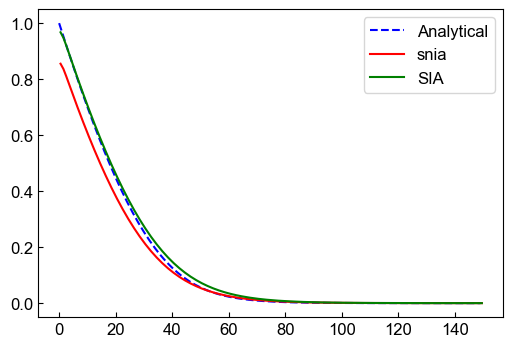

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# %matplotlib inline
# %config InlineBackend.figure_format = 'svg'
config = {'font.family': 'Arial',
          'font.size': 12,
          'xtick.direction': 'in',
          'ytick.direction': 'in',
          'mathtext.fontset': 'stix',
          'savefig.dpi': 300
         }
plt.rcParams.update(config)

# Read mf6pqc results pH Cl Mg Ca Calcite Dolomite
mf6pqc_data = np.load("./output/results_snia.npy")
print(mf6pqc_data.shape)

# mf6pqc_data = mf6pqc_data[-1].reshape(-1)

# Read pht3d results [Ca Mg Cl pH Calcite Dolomite]
# pht3d_data = np.load("./input_data/PHT3D_results.npy")

import flopy

model_ws = "./simulation/"
model_name = "model"

nlay, nrow, ncol = 57, 1, 135

# 读取离散化文件（DIS）
sim = flopy.mf6.MFSimulation.load(sim_ws=model_ws, sim_name=model_name, verbosity_level=0)
gwf = sim.get_model("gwf_model")
bud = sim.get_model("gwf_model").output.budget()
# 读取所有SPDIS数据
# spdis_all = bud.get_data(text='DATA-SPDIS')
# spdis_all = bud.get_data(text='FLOW-JA-FACE')

Spe_data = sim.get_model("gwt_Spe_model").output.concentration().get_alldata()
print(Spe_data.shape)

# ! 解析解
from scipy.optimize import bisect
def find_C(x_target, vp=0.1, vmax=4.77e-3, K=0.5, C0=1.0):
    def f(C):
        return (vp / vmax) * (K * np.log(C0/C) + C0 - C) - x_target
    C = bisect(f, 1e-6, 1)
    return C

x_values = np.linspace(0, 149, 150)
C_values = np.array([find_C(x) for x in x_values])

it = 20

plt.figure(figsize=(6,4))
plt.plot(x_values, C_values, linestyle='--', color='b', label="Analytical") # , marker='o'
plt.plot(x_values+0.5, mf6pqc_data[-1, 0, :], color='r', label="snia")
# plt.plot(x_values+0.5, mf6pqc_data1[it+1, 0, :], color='r', linestyle='--', label="from results array")
# plt.plot(x_values+0.5, mf6pqc_data1[-1, 0, :],linestyle='--', color='r', label="from results array")
plt.plot(x_values+0.5, Spe_data[-1, 0, 0, :], color='g', label="SIA")
# plt.plot(x_values+0.5, Spe_data1[it, 0, 0, :], color='g', linestyle='--', label="from MODFLOW6 output")

plt.legend()

print("SNIA: ", np.linalg.norm(mf6pqc_data[-1, 0, :] - C_values) / np.linalg.norm(C_values))
print("SIA: ", np.linalg.norm(Spe_data[-1, 0, :] - C_values) / np.linalg.norm(C_values))


In [7]:
mf6pqc_data1 = mf6pqc_data.copy()
Spe_data1 = Spe_data.copy()